# Run TGLF from input.gacode

For this tutorial we will need the following modules:

In [3]:
from mitim_tools.gacode_tools import TGLFtools
from mitim_tools.misc_tools   import IOtools

Select the location of the input.gacode file to start the simulation from. Note that you can use the ``IOtools.expandPath()`` method to work with relative paths. You should also select the folder where the simulation will be run:

In [4]:
inputgacode_file = IOtools.expandPath('$MITIM_PATH/tests/data/input.gacode')
folder           = IOtools.expandPath('$MITIM_PATH/tests/scratch/tglf_tut/')

The TGLF class can be initialized by providing the radial location (in square root of normalized toroidal flux, ``rho``) to run. Note that the values are given as a list, and several radial locations can be run at once:

In [5]:
tglf = TGLFtools.TGLF(rhos=[0.5, 0.7])

 
----------------------------------------------------------------------------------------- 
 			 TGLF class module 
 -----------------------------------------------------------------------------------------
 


To generate the input files (input.tglf) to TGLF at each radial location, MITIM needs to run a few commands to correctly map the quantities in the input.gacode file to the ones required by TGLF. This is done automatically with the ``prep()`` command. Note that MITIM has a *only-run-if-needed* philosophy and if it finds that the input files to TGLF already exist in the working folder, the preparation method will not run any command, unless a ``restart = True`` argument is provided.

In [6]:
cdf = tglf.prep(folder,inputgacode=inputgacode_file,restart=False )

 > Preparation of TGLF run 
 	- Custom input.gacode class used 
 	- Testing... do TGLF files already exist? 
 		- Testing /Users/pablorf/MITIM-fusion//tests/scratch/tglf_tut///input.tglf_0.5000 
 		- Testing /Users/pablorf/MITIM-fusion//tests/scratch/tglf_tut///input.tglf_0.7000 
 		- All input files to TGLF exist, not running scans 
 	- Entering in TGLF scans module (running a dummy zero-iteration TGYRO)... 
 		- No need to run dummy iteration of TGYRO 
 	- Creating dictionary with all input files generated by TGLF_scans 
 > Setting up normalizations 
 	- Using mass of deuterium to normalize things (not necesarily the first ion) 


.. tip::

    The ``.prep()`` method, when applied to a case that starts with an input.gacode file, launches a `TGYRO` run for a "zero" iteration to generate *input.tglf* at specific ``rho`` locations from the *input.gacode*. This method to generate input files is inspired by how the `OMFIT framework <https://omfit.io/index.html>`_ works.

Now, we are ready to run TGLF. Once the ``prep()`` command has finished, one can run TGLF with different settings and assumptions. That is why, at this point, a sub-folder name for this specific run can be provided. Similarly to the ``prep()`` command, a ``restart`` flag can be provided.
The set of control inputs to TGLF (like saturation rule, electromagnetic effects, etc.) are provided in two ways.
First, the argument ``TGLFsettings`` indicates the base case to start with.
The user is referred to ``templates/input.tglf.models.json`` to understand the meaning of each setting, and ``templates/input.tglf.controls`` for the default setup.
Second, the argument ``extraOptions`` can be passed as a dictionary of variables to change.
For example, the following two commands will run TGLF with saturation rule number 2 with and without electromagnetic effets. After each ``run()`` command, a ``read()`` is needed, to populate the *tglf.results* dictionary with the TGLF outputs (``label`` refers to the dictionary key for each run):


In [8]:
tglf.run( subFolderTGLF = 'yes_em_folder/', 
            TGLFsettings  = 5,
            extraOptions  = {},
            restart       = True,
            forceIfRestart= True)

tglf.read( label = 'yes_em' )

tglf.run( subFolderTGLF = 'no_em_folder/', 
            TGLFsettings  = 5,
            extraOptions  = {'USE_BPER':False},
            restart       = True,
            forceIfRestart= True)

tglf.read( label = 'no_em' )

 		~ Folder ...//tests/scratch/tglf_tut//yes_em_folder/ created
 	- Changing input file for rho=0.5000 
  	- Using presets TGLFsettings = 5 (SAT2em) 
 	- Applying corrections 
 			* Species 5 removed because it is not a thermal specie 
 			* Total species to run TGLF with reduced to 4 
 	- Writting TGLF input file 
 		~ File ...lf_tut//yes_em_folder//input.tglf_0.5000 written 
 	- Changing input file for rho=0.7000 
  	- Using presets TGLFsettings = 5 (SAT2em) 
 	- Applying corrections 
 			* Species 5 removed because it is not a thermal specie 
 			* Total species to run TGLF with reduced to 4 
 	- Writting TGLF input file 
 		~ File ...lf_tut//yes_em_folder//input.tglf_0.7000 written 
 	- Slurm job will be submitted with 8 cores (2 radii x 4 cores/radius) 
 
> Run TGLF 
 		~ Folder ...ratch/tglf_tut//yes_em_folder//tmp_tglf/ created
 	- Preparing TGLF at rho=0.5000 
 	- Preparing TGLF at rho=0.7000 
 	- Slurm Settings: 
 		- Job settings: 
 			- minutes: 5 
 			- ntasks: 2 
 			- nam

                    mitim_send.tar.gz: 100%|██████████| 2.36k/2.36k [105kB/s]

 		- Extracting tarball 


 		- Removing tarballs 
 	* Executing (remote): 
 		cd /pool001/pablorf/scratch//mitim_tglf_0yes_em_folder_exe/ && bash mitim_shell_executor.sh > mitim.out 
 	* Retrieving files from remote server: 
 		- Removing local output files & folders that potentially exist from previous runs 
 		- Tarballing 
 		- Downloading 


                    mitim_receive.tar.gz: 100%|██████████| 76.2k/76.2k [588kB/s]

...

                    mitim_send.tar.gz: 100%|██████████| 2.48k/2.48k [10.0kB/s]


 		- Extracting tarball 
 		- Removing tarballs 
 	* Executing (remote): 
 		cd /pool001/pablorf/scratch//mitim_tglf_0no_em_folder_exe/ && bash mitim_shell_executor.sh > mitim.out 
 	* Retrieving files from remote server: 
 		- Removing local output files & folders that potentially exist from previous runs 
 		- Tarballing 
 		- Downloading 


                    mitim_receive.tar.gz: 100%|██████████| 53.3k/53.3k [371kB/s]

 		- Extracting tarball 
 		- Removing tarballs 


 	* Checking if all expected files & folders were received 
 		- All correct 
 	* Removing remote folder 
 	* Closing connection 
 	-------------- Finished process (took 1.0min 33.0s) --------------
 
 	- Retrieving files and changing names for storing 
 		- All files were successfully retrieved 
 > Reading TGLF results 
 	- Reading results from folder ...n//tests/scratch/tglf_tut//no_em_folder/ with suffix _0.5000 
 		- For Qi, summing contributions from ions (1, 2, 3) (#0 is e-) 
 		- For Qi spectrum, summing contributions from ions (1, 2, 3) (#0 is e-) 
 	- TGLF was run with 4 species, 6 modes, 1 field(s) (phi), 28 wavenumbers 
 	- Reading results from folder ...n//tests/scratch/tglf_tut//no_em_folder/ with suffix _0.7000 
 		- For Qi, summing contributions from ions (1, 2, 3) (#0 is e-) 
 		- For Qi spectrum, summing contributions from ions (1, 2, 3) (#0 is e-) 
 	- TGLF was run with 4 species, 6 modes, 1 field(s) (phi), 28 wavenumbers 


.. tip::

    In this example, ``tglf.results['yes_em']`` and ``tglf.results['no_em']`` are themselves dictionaries, so please do ``.keys()`` to get all the possible results that have been obtained.

TGLF results can be plotted together by indicating what labels to plot:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


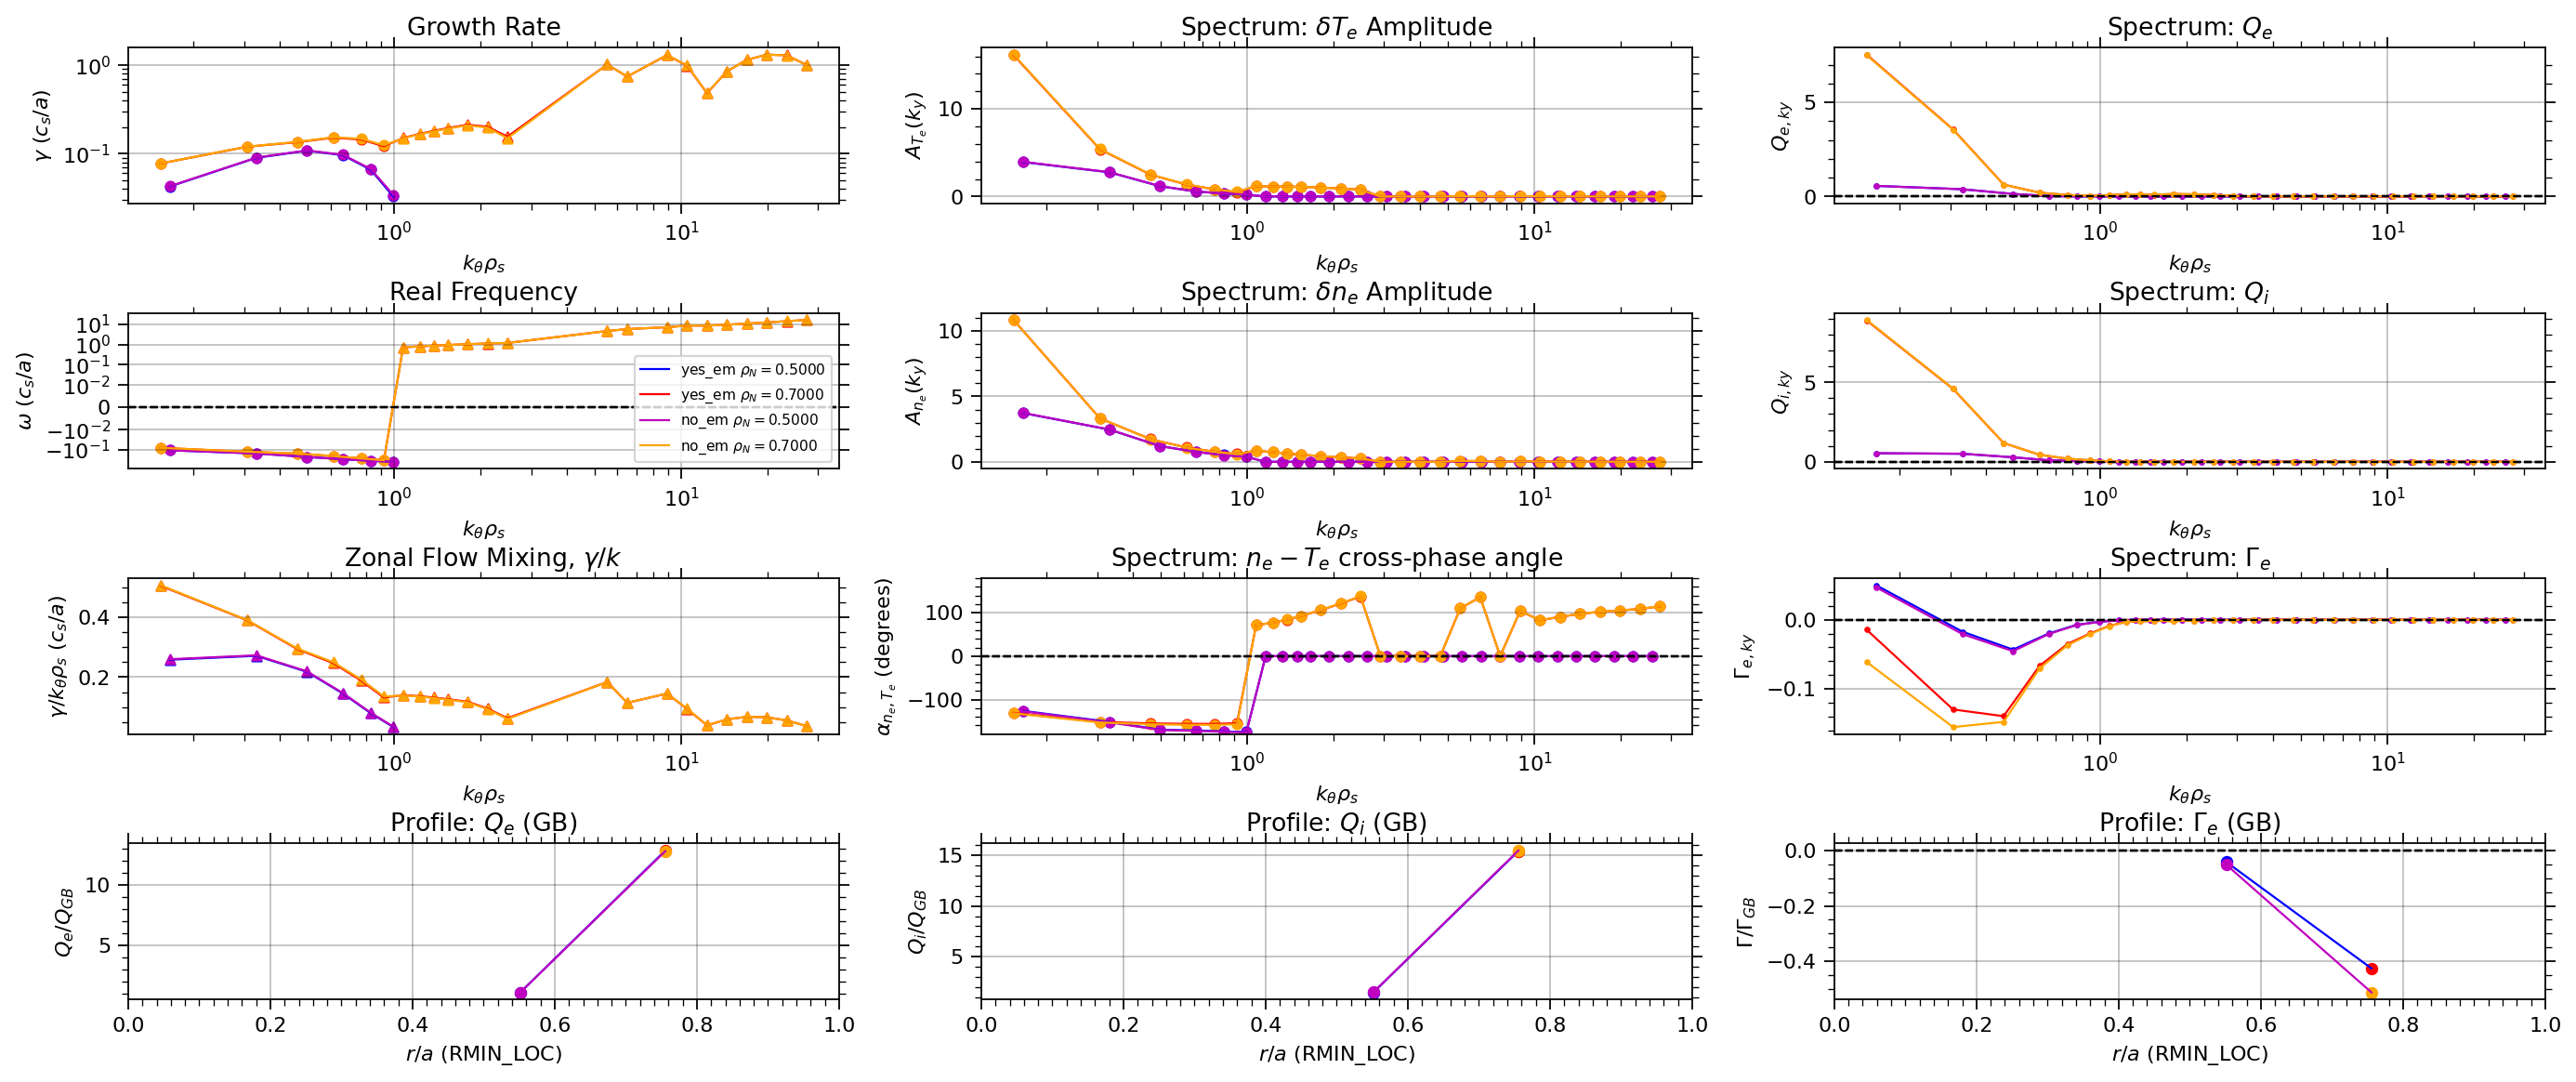

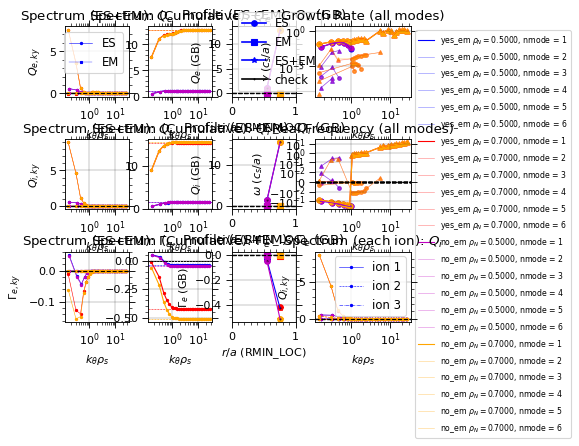

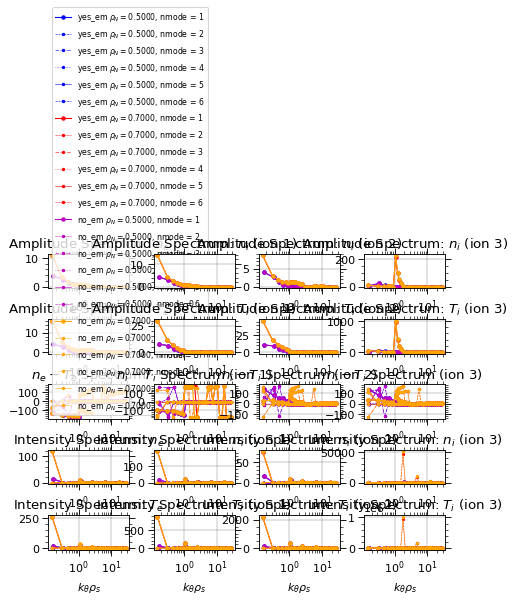

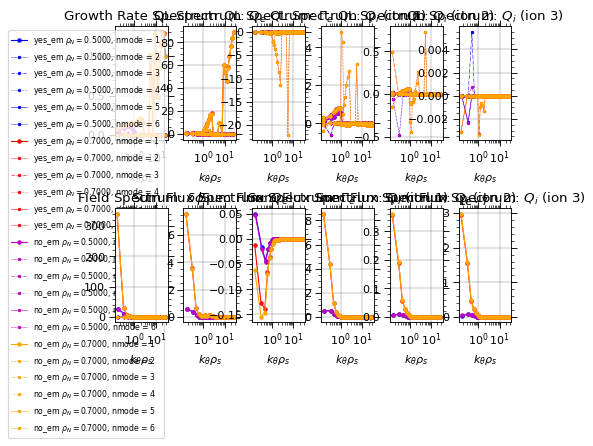

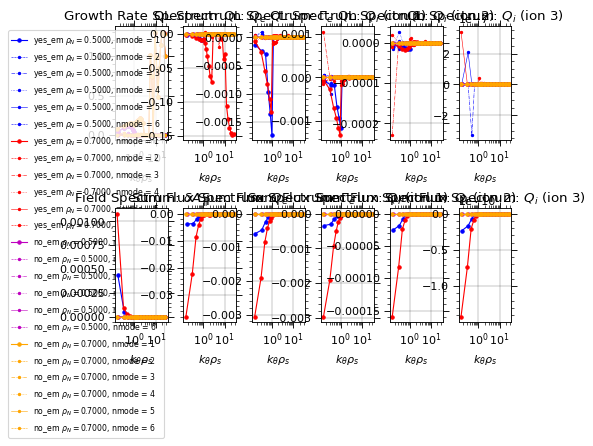

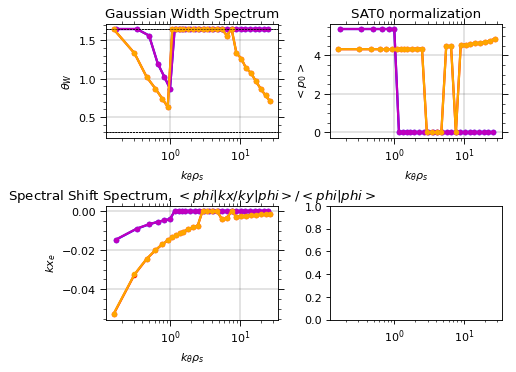

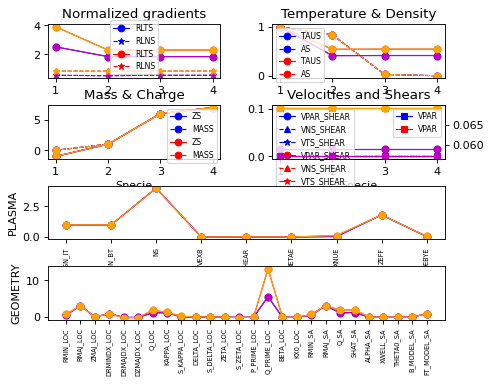

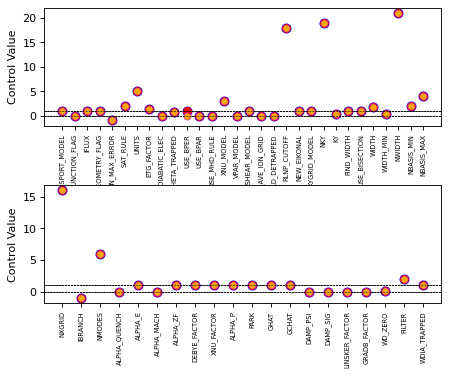

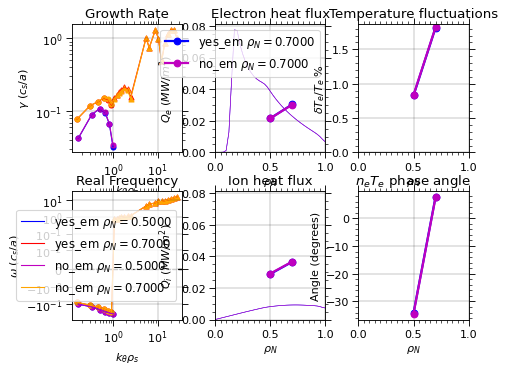

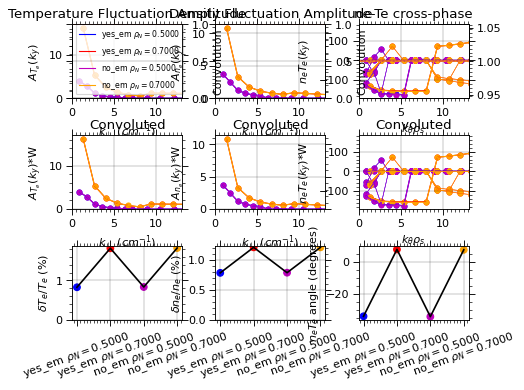

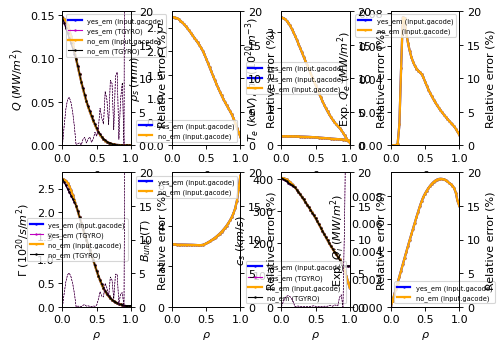

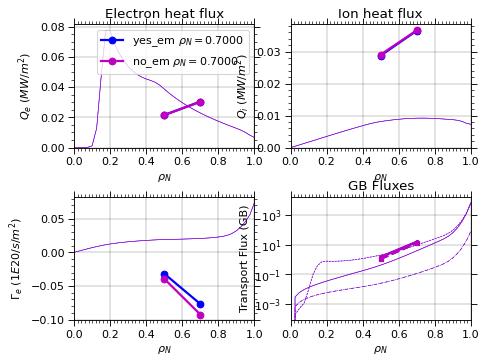

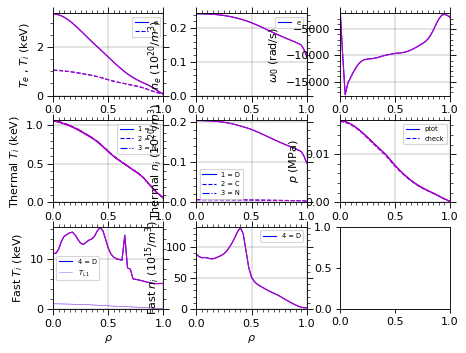

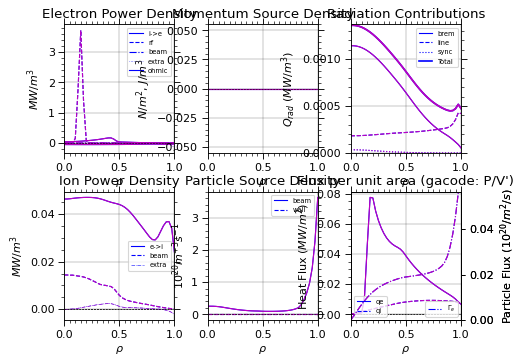

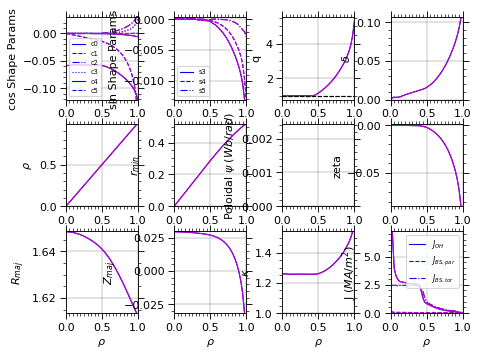

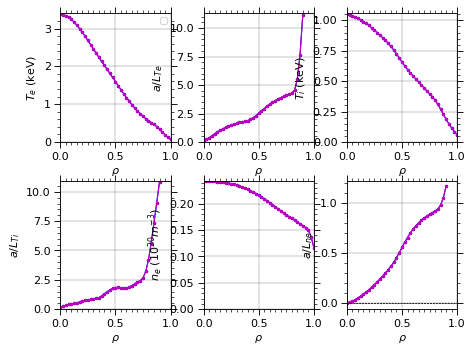

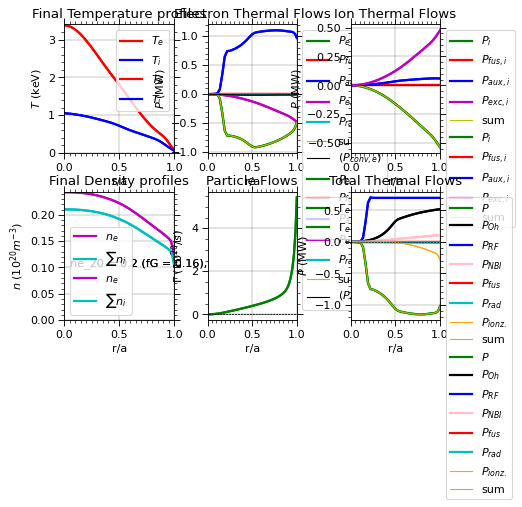

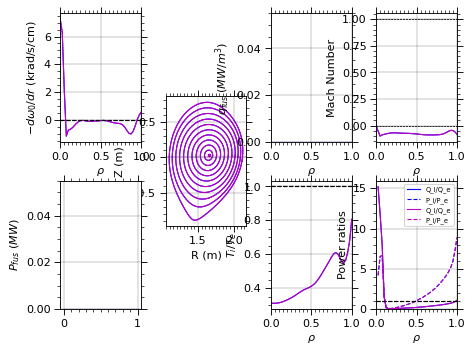

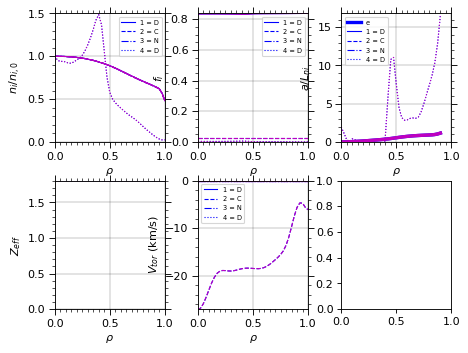

In [9]:
tglf.plot( labels = ['yes_em', 'no_em'] )

As a result, a TGLF notebook with different tabs will be opened with all relevant output quantities:

.. image:: ./figs/TGLFnotebook.png
   :align: center
   :alt: TGLF_Notebook
